# Estimating 99% VaR using a Univariate GARCH Approach

We begin our analysis with some light exploratory data analysis. Then, we construct the Standardized Skew Student-t distribution with a generalized pareto (left) tail and apply a soft multiplier, then we run our GARCH-GPD model. 

We will be establishing the statistical soundness of our estimated 99% Value at Risk (VaR) using adequacy and accuracy tests, along with firm and industry loss functions. This work stems from a coursework exercise from Bayes (Cass) Business School, City University of London.

In [1]:
from arch import arch_model
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
pd.set_option('display.float_format', '{:,.6f}'.format)  # set the pandas display option to format decimals for better readability
pd.set_option('display.max_columns', None)      # Show all columns
pd.set_option('display.width', 0)               # No limit on line width (side by side)
pd.set_option('display.max_colwidth', None)     # Show full content in each column

In [3]:
portfolio_df = pd.read_csv("Portfolio.csv")
portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'])
portfolio_df = portfolio_df.set_index('Date')
portfolio_df

,Value
Date,
1974-01-02,97.680000
1974-01-03,99.800000
1974-01-04,98.900000
1974-01-07,98.070000
1974-01-08,96.120000
...,...
2024-06-10,"5,360.790000"
2024-06-11,"5,375.320000"
2024-06-12,"5,421.030000"


In [4]:
portfolio_df.describe()

,Value
count,"12,724.000000"
mean,"1,162.968122"
std,"1,174.770423"
min,62.280000
25%,238.567500
50%,933.475000
75%,"1,449.130000"
max,"5,433.740000"


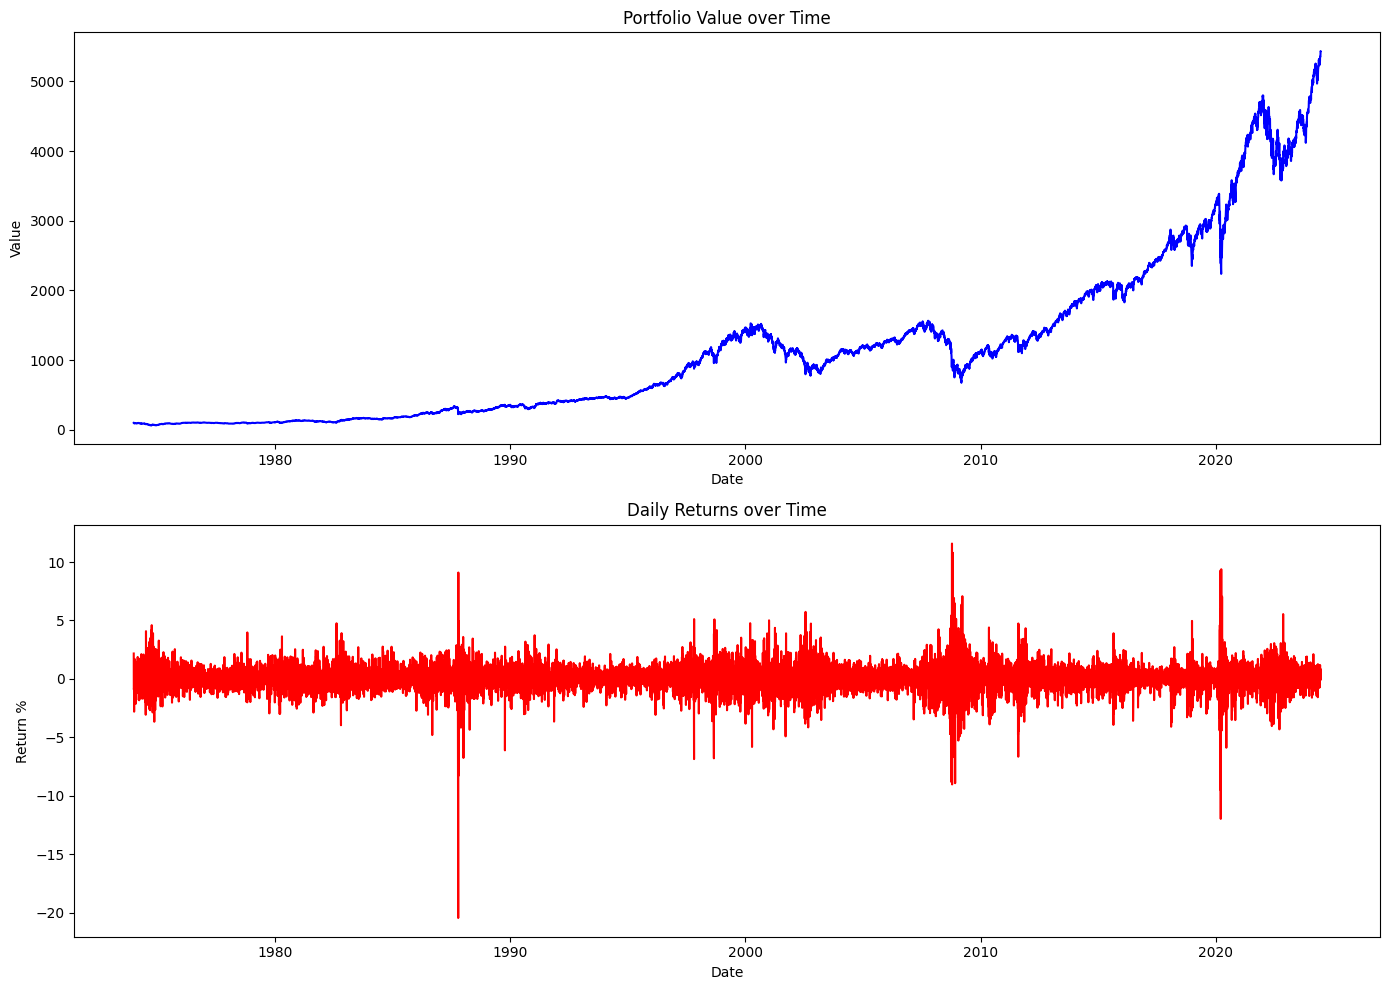

In [5]:
# Calculate daily returns
portfolio_df['Return'] = portfolio_df['Value'].pct_change() * 100  # in percent
portfolio_df = portfolio_df.dropna()
returns = portfolio_df['Return'].values

# Plot portfolio value and returns
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(portfolio_df['Value'], color='blue')
axes[0].set_title('Portfolio Value over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Value')

axes[1].plot(portfolio_df['Return'], color='red')
axes[1].set_title('Daily Returns over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return %')

plt.tight_layout()
plt.show()

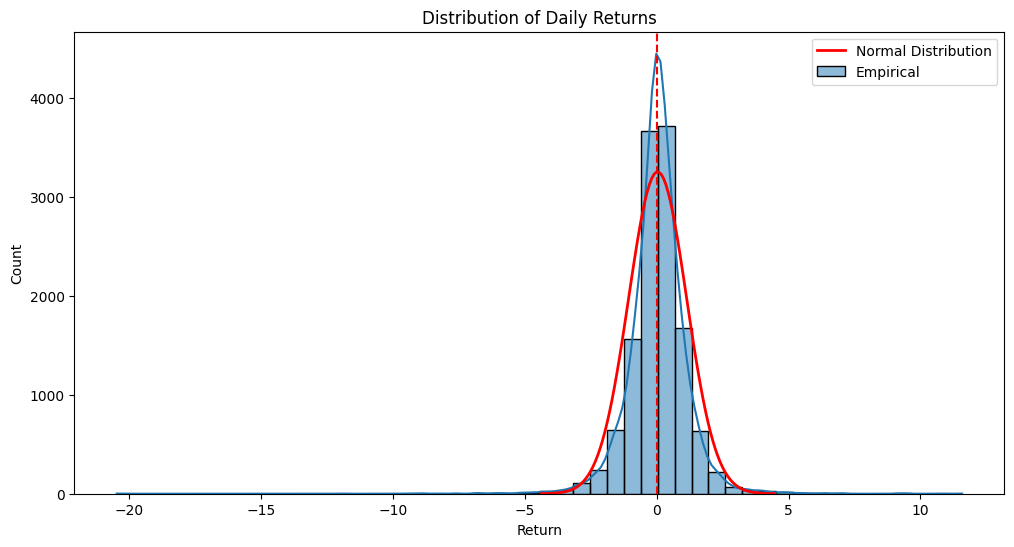

In [6]:
# Check return distribution
plt.figure(figsize=(12, 6))
sns.histplot(portfolio_df['Return'], kde=True, bins=50, label='Empirical')
plt.title('Distribution of Daily Returns')
plt.axvline(x=0, color='red', linestyle='--')

# Add a normal distribution for reference
mu, std = portfolio_df['Return'].mean(), portfolio_df['Return'].std()
x = np.linspace(mu - 4*std, mu + 4*std, 100)
plt.plot(x, stats.norm.pdf(x, mu, std) * len(portfolio_df['Return']) * (plt.gca().get_xlim()[1] - plt.gca().get_xlim()[0]) / 50, 'r-', lw=2, label='Normal Distribution')
plt.legend()
plt.show()


In [7]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.6f}')

    if result[1] <= 0.05:
        print('\nSeries is Stationary (reject H0)')
    else:
        print('\nSeries is Non-Stationary (fail to reject H0)')
    
print('\nStationarity Test for Returns:')
check_stationarity(portfolio_df['Return'])


Stationarity Test for Returns:
ADF Statistic: -20.179206
p-value: 0.000000
Critical Values:
	1%: -3.430865
	5%: -2.861768
	10%: -2.566891

Series is Stationary (reject H0)


In [8]:
def check_heteroskedasticity(series):
    result = het_arch(series)
    print('\nARCH LM Test:')
    print(f'LM Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'F-Statistic: {result[2]:.6f}')
    print(f'p-value (F): {result[3]:.6f}')

    if result[1] < 0.05:
        print('\nARCH effect detected! (reject H0)')
    else:
        print('\nNo ARCH effect detected! (fail to reject H0)')

print('\nARCH-LM (Heteroskedasticity) Test:')
check_heteroskedasticity(portfolio_df['Return'])


ARCH-LM (Heteroskedasticity) Test:

ARCH LM Test:
LM Statistic: 1949.577693
p-value: 0.000000
F-Statistic: 230.071209
p-value (F): 0.000000

ARCH effect detected! (reject H0)


In [9]:
# Create empty results dataframe to store our results
results_data = []

In [10]:
# Set up train/test split
train_size = int(len(returns) * 0.8)  # 80-20 train-test split
train_returns = returns[:train_size]
test_returns = returns[train_size:]
test_dates = pd.date_range(start='2014-01-01', periods=len(test_returns))
alpha = 0.01  # for 99% confidence level

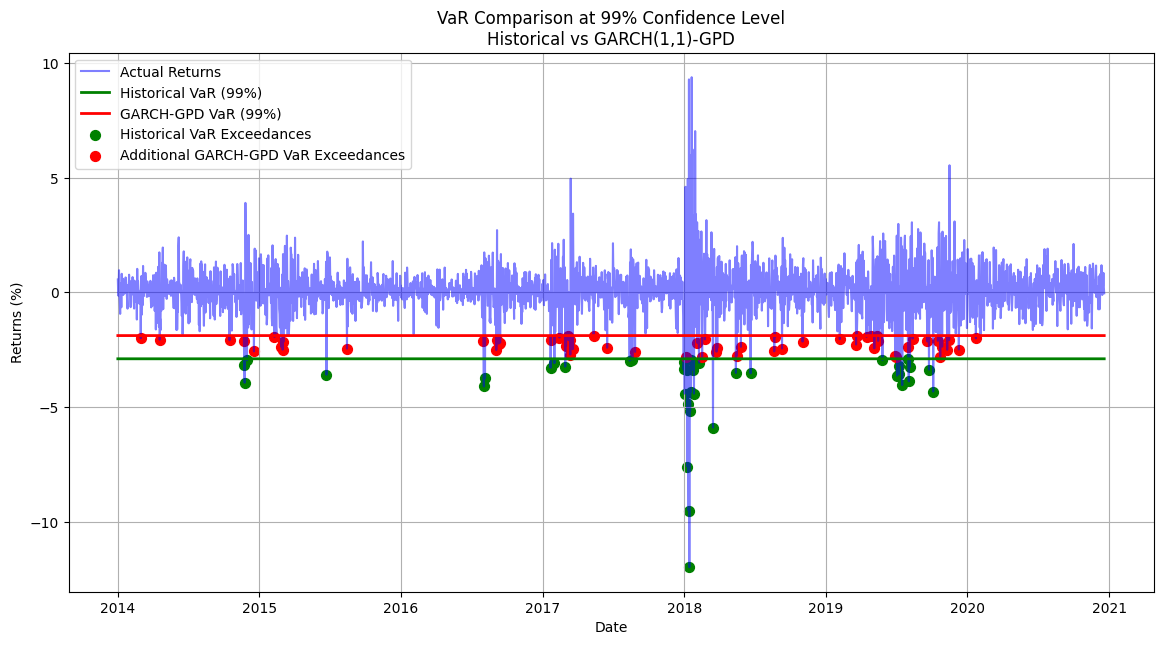


Summary Statistics:
Historical VaR Exceedance Rate: 0.0149 (38 out of 2545)
GARCH-GPD VaR Exceedance Rate: 0.0377 (96 out of 2545)
Target Rate: 0.0100


In [11]:
# Calculate Historical VaR
hist_var = np.percentile(train_returns, alpha*100)
test_var_hist = [hist_var] * len(test_returns)
hist_exceedances = [1 if r < var else 0 for r, var in zip(test_returns, test_var_hist)]
hist_rate = sum(hist_exceedances) / len(test_returns)

# Add Historical VaR results to results_data
results_data.append({
    'model': 'Historical',
    'distribution': 'Empirical',
    'p': '-',
    'q': '-',
    'var_estimate': hist_var,
    'exceedance_rate': hist_rate,
    'exceedance_count': sum(hist_exceedances),
    'expected_rate': alpha,
    'total_observations': len(test_returns)
})

# Fit base GARCH model with skewed-t distribution
base_model = arch_model(returns, vol='Garch', p=1, q=1, dist='skewt').fit(disp='off')

# Extract standardized residuals
std_residuals = base_model.resid / base_model.conditional_volatility
left_tail_percentile = 5  # 5% left tail
left_tail_threshold = np.percentile(std_residuals, left_tail_percentile)
exceedances = -(std_residuals[std_residuals <= left_tail_threshold] - left_tail_threshold)

# Fit GPD to the exceedances
shape, loc, scale = stats.genpareto.fit(exceedances)

# Fit model on training data
train_model = arch_model(train_returns, vol='Garch', p=1, q=1, dist='skewt').fit(disp='off')
train_std_residuals = train_model.resid / train_model.conditional_volatility
train_left_tail_threshold = np.percentile(train_std_residuals, left_tail_percentile)
train_exceedances = -(train_std_residuals[train_std_residuals <= train_left_tail_threshold] - train_left_tail_threshold)
train_shape, train_loc, train_scale = stats.genpareto.fit(train_exceedances)

# Calculate excess probability and GPD quantile
excess_prob = alpha / (left_tail_percentile/100)
train_excess = train_scale/train_shape * (excess_prob**(-train_shape) - 1) if train_shape != 0 else -train_scale * np.log(excess_prob)
train_gpd_quantile = train_left_tail_threshold - train_excess

# Generate VaR forecasts
test_var_gpd = []
for i in range(len(test_returns)):
    forecast = train_model.forecast(horizon=1)
    vol = np.sqrt(forecast.variance.iloc[-1, 0])
    var_val = train_gpd_quantile * vol
    test_var_gpd.append(var_val)

# Calculate GARCH-GPD exceedances
gpd_exceedances = [1 if r < var else 0 for r, var in zip(test_returns, test_var_gpd)]
gpd_rate = sum(gpd_exceedances) / len(test_returns)

# Add GARCH-GPD results to results_data
results_data.append({
    'model': 'GARCH(1,1)-GPD',
    'distribution': 'GPD-Hybrid',
    'p': 1,
    'q': 1,
    'var_estimate': test_var_gpd[-1],
    'exceedance_rate': gpd_rate,
    'exceedance_count': sum(gpd_exceedances),
    'expected_rate': alpha,
    'total_observations': len(test_returns),
    'gpd_shape': shape,
    'gpd_scale': scale,
    'multiplier': 1.0
})

# Create combined plot
plt.figure(figsize=(14, 7))

# Plot returns and VaR lines
plt.plot(test_dates, test_returns, 'b-', label='Actual Returns', alpha=0.5)
plt.plot(test_dates, test_var_hist, 'g-', label='Historical VaR (99%)', linewidth=2)
plt.plot(test_dates, test_var_gpd, 'r-', label='GARCH-GPD VaR (99%)', linewidth=2)

# Plot exceedances with correct coloring
hist_exceed_dates = []
hist_exceed_values = []
gpd_exceed_dates = []
gpd_exceed_values = []

for date, r, hist_var, gpd_var in zip(test_dates, test_returns, test_var_hist, test_var_gpd):
    if r < hist_var:
        # If return breaches Historical VaR, mark it green
        hist_exceed_dates.append(date)
        hist_exceed_values.append(r)
    if r < gpd_var and r >= hist_var:
        # If return breaches GARCH-GPD VaR but not Historical VaR, mark it red
        gpd_exceed_dates.append(date)
        gpd_exceed_values.append(r)

# Plot Historical VaR exceedances (green)
if hist_exceed_dates:
    plt.scatter(hist_exceed_dates, hist_exceed_values, color='green', s=50,
                label='Historical VaR Exceedances')

# Plot GARCH-GPD only exceedances (red)
if gpd_exceed_dates:
    plt.scatter(gpd_exceed_dates, gpd_exceed_values, color='red', s=50,
                label='Additional GARCH-GPD VaR Exceedances')

plt.title('VaR Comparison at 99% Confidence Level\nHistorical vs GARCH(1,1)-GPD')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Historical VaR Exceedance Rate: {hist_rate:.4f} ({sum(hist_exceedances)} out of {len(test_returns)})")
print(f"GARCH-GPD VaR Exceedance Rate: {gpd_rate:.4f} ({sum(gpd_exceedances)} out of {len(test_returns)})")
print(f"Target Rate: {alpha:.4f}")


Multiplier 1.1:
Exceedance Rate: 0.0310 (79 out of 2545)
Target Rate: 0.0100

Multiplier 1.2:
Exceedance Rate: 0.0255 (65 out of 2545)
Target Rate: 0.0100

Multiplier 1.3:
Exceedance Rate: 0.0220 (56 out of 2545)
Target Rate: 0.0100

Multiplier 1.4:
Exceedance Rate: 0.0177 (45 out of 2545)
Target Rate: 0.0100

Multiplier 1.5:
Exceedance Rate: 0.0149 (38 out of 2545)
Target Rate: 0.0100

Multiplier 1.6:
Exceedance Rate: 0.0126 (32 out of 2545)
Target Rate: 0.0100

Multiplier 1.7:
Exceedance Rate: 0.0110 (28 out of 2545)
Target Rate: 0.0100

Multiplier 1.8:
Exceedance Rate: 0.0083 (21 out of 2545)
Target Rate: 0.0100

Best multiplier: 1.7
Exceedance rate: 0.0110


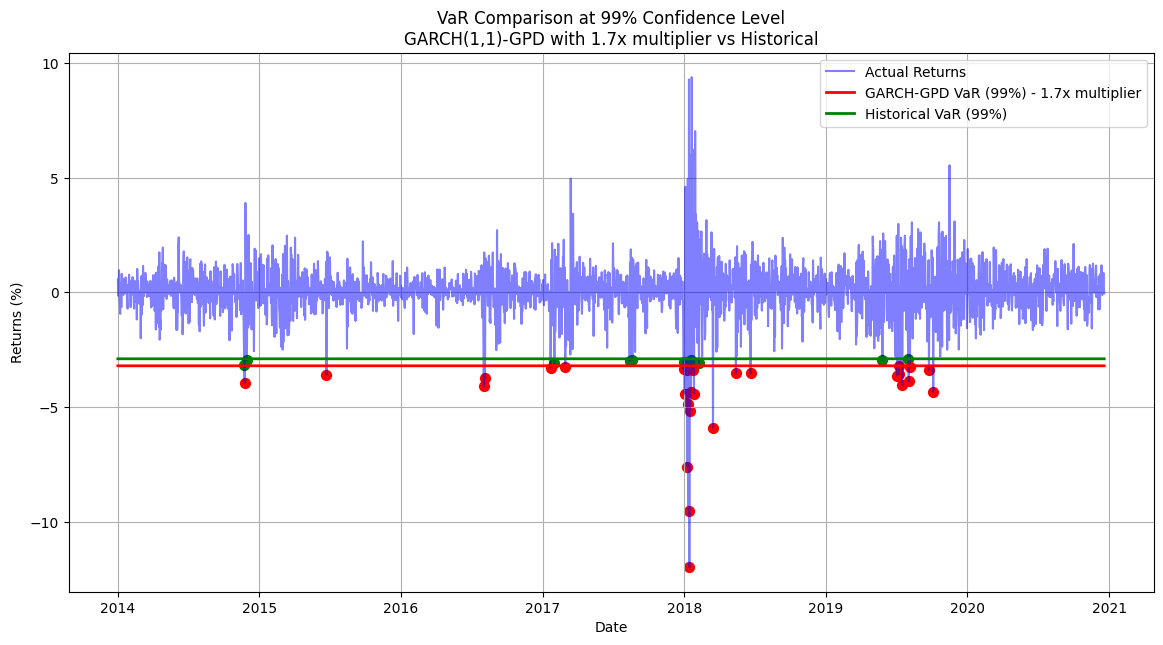

In [12]:
# First run the GPD-Skewt base calculation (from previous code)
base_model = arch_model(returns, vol='Garch', p=1, q=1, dist='skewt').fit(disp='off')
std_residuals = base_model.resid / base_model.conditional_volatility
left_tail_percentile = 5
left_tail_threshold = np.percentile(std_residuals, left_tail_percentile)
exceedances = -(std_residuals[std_residuals <= left_tail_threshold] - left_tail_threshold)
shape, loc, scale = stats.genpareto.fit(exceedances)

# Calculate Historical VaR (will be used in all plots)
hist_var = np.percentile(train_returns, alpha*100)
test_var_hist = [hist_var] * len(test_returns)
hist_exceedances = [1 if r < var else 0 for r, var in zip(test_returns, test_var_hist)]
hist_rate = sum(hist_exceedances) / len(test_returns)

# Calculate base GPD VaR
train_model = arch_model(train_returns, vol='Garch', p=1, q=1, dist='skewt').fit(disp='off')
train_std_residuals = train_model.resid / train_model.conditional_volatility
train_left_tail_threshold = np.percentile(train_std_residuals, left_tail_percentile)
train_exceedances = -(train_std_residuals[train_std_residuals <= train_left_tail_threshold] - train_left_tail_threshold)
train_shape, train_loc, train_scale = stats.genpareto.fit(train_exceedances)

excess_prob = alpha / (left_tail_percentile/100)
train_excess = train_scale/train_shape * (excess_prob**(-train_shape) - 1) if train_shape != 0 else -train_scale * np.log(excess_prob)
train_gpd_quantile = train_left_tail_threshold - train_excess

# Generate base VaR forecasts
base_test_var_gpd = []
for i in range(len(test_returns)):
    forecast = train_model.forecast(horizon=1)
    vol = np.sqrt(forecast.variance.iloc[-1, 0])
    var_val = train_gpd_quantile * vol
    base_test_var_gpd.append(var_val)

# Test different multipliers
multipliers = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
multiplier_results = {}

for multiplier in multipliers:
    # Calculate VaR with multiplier
    test_var_gpd = [var * multiplier for var in base_test_var_gpd]

    # Calculate exceedances
    gpd_exceedances = [1 if r < var else 0 for r, var in zip(test_returns, test_var_gpd)]
    gpd_rate = sum(gpd_exceedances) / len(test_returns)

    # Store results
    multiplier_results[multiplier] = {
        'exceedance_rate': gpd_rate,
        'exceedance_count': sum(gpd_exceedances),
        'vars': test_var_gpd
    }
    
    # Add results to results_data
    results_data.append({
        'model': f'GARCH(1,1)-GPD-{multiplier}x',
        'distribution': 'GPD-Hybrid',
        'p': 1,
        'q': 1,
        'var_estimate': test_var_gpd[-1],  # Using the last VaR estimate
        'exceedance_rate': gpd_rate,
        'exceedance_count': sum(gpd_exceedances),
        'expected_rate': alpha,
        'total_observations': len(test_returns),
        'gpd_shape': shape,
        'gpd_scale': scale,
        'multiplier': multiplier
    })

    # Print results
    print(f"\nMultiplier {multiplier:.1f}:")
    print(f"Exceedance Rate: {gpd_rate:.4f} ({sum(gpd_exceedances)} out of {len(test_returns)})")
    print(f"Target Rate: {alpha:.4f}")

# Find best multiplier
differences = {m: abs(multiplier_results[m]['exceedance_rate'] - alpha) for m in multipliers}
best_multiplier = min(differences.items(), key=lambda x: x[1])[0]

print(f"\nBest multiplier: {best_multiplier:.1f}")
print(f"Exceedance rate: {multiplier_results[best_multiplier]['exceedance_rate']:.4f}")

# Plot results with best multiplier
plt.figure(figsize=(14, 7))

# Plot returns
plt.plot(test_dates, test_returns, 'b-', label='Actual Returns', alpha=0.5)

# Plot VaR lines
plt.plot(test_dates, multiplier_results[best_multiplier]['vars'], 'r-',
         label=f'GARCH-GPD VaR (99%) - {best_multiplier}x multiplier', linewidth=2)
plt.plot(test_dates, test_var_hist, 'g-', label='Historical VaR (99%)', linewidth=2)

# Plot exceedances with correct coloring
all_exceedances = []
for i, (date, r, gpd_var, hist_var) in enumerate(zip(
    test_dates,
    test_returns,
    multiplier_results[best_multiplier]['vars'],
    test_var_hist
)):
    if r < gpd_var:
        # GARCH-GPD exceedance - RED
        all_exceedances.append({
            'date': date,
            'value': r,
            'color': 'red',
            'label': 'GARCH-GPD VaR Exceedances' if i == 0 else None
        })
    elif r < hist_var:
        # Historical VaR exceedance only - GREEN
        all_exceedances.append({
            'date': date,
            'value': r,
            'color': 'green',
            'label': 'Historical VaR Exceedances' if i == 0 else None
        })

# Plot exceedances
for color in ['green', 'red']:
    points = [e for e in all_exceedances if e['color'] == color]
    if points:
        dates = [p['date'] for p in points]
        values = [p['value'] for p in points]
        label = next((p['label'] for p in points if p['label']), None)
        plt.scatter(dates, values, color=color, s=50, label=label)

plt.title(f'VaR Comparison at 99% Confidence Level\nGARCH(1,1)-GPD with {best_multiplier:.1f}x multiplier vs Historical')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Convert to DataFrame
results_df = pd.DataFrame(results_data)

results_df

,model,distribution,p,q,var_estimate,exceedance_rate,exceedance_count,expected_rate,total_observations,gpd_shape,gpd_scale,multiplier
0,Historical,Empirical,-,-,-2.895399,0.014931,38,0.010000,2545,NaN,NaN,NaN
1,"GARCH(1,1)-GPD",GPD-Hybrid,1,1,-1.882952,0.037721,96,0.010000,2545,0.115036,0.595120,1.000000
2,"GARCH(1,1)-GPD-1.1x",GPD-Hybrid,1,1,-2.071247,0.031041,79,0.010000,2545,0.115036,0.595120,1.100000
3,"GARCH(1,1)-GPD-1.2x",GPD-Hybrid,1,1,-2.259542,0.025540,65,0.010000,2545,0.115036,0.595120,1.200000
4,"GARCH(1,1)-GPD-1.3x",GPD-Hybrid,1,1,-2.447837,0.022004,56,0.010000,2545,0.115036,0.595120,1.300000
5,"GARCH(1,1)-GPD-1.4x",GPD-Hybrid,1,1,-2.636132,0.017682,45,0.010000,2545,0.115036,0.595120,1.400000
6,"GARCH(1,1)-GPD-1.5x",GPD-Hybrid,1,1,-2.824427,0.014931,38,0.010000,2545,0.115036,0.595120,1.500000
7,"GARCH(1,1)-GPD-1.6x",GPD-Hybrid,1,1,-3.012722,0.012574,32,0.010000,2545,0.115036,0.595120,1.600000
8,"GARCH(1,1)-GPD-1.7x",GPD-Hybrid,1,1,-3.201018,0.011002,28,0.010000,2545,0.115036,0.595120,1.700000
9,"GARCH(1,1)-GPD-1.8x",GPD-Hybrid,1,1,-3.389313,0.008251,21,0.010000,2545,0.115036,0.595120,1.800000


In [14]:
# First, create the model_data dictionary
model_data = {}

# Add Historical VaR data
model_data['Historical'] = {
    'vars': test_var_hist,
    'exceedances': hist_exceedances,
    'rate': hist_rate
}

# Add base GARCH-GPD data
model_data['GARCH(1,1)-GPD'] = {
    'vars': base_test_var_gpd,
    'exceedances': gpd_exceedances,
    'rate': gpd_rate
}

# Add data for each multiplier
for multiplier in multipliers:
    model_name = f'GARCH(1,1)-GPD-{multiplier}x'
    test_var_gpd = multiplier_results[multiplier]['vars']
    gpd_exceedances = [1 if r < var else 0 for r, var in zip(test_returns, test_var_gpd)]
    gpd_rate = sum(gpd_exceedances) / len(test_returns)

    model_data[model_name] = {
        'vars': test_var_gpd,
        'exceedances': gpd_exceedances,
        'rate': gpd_rate
    }

## Statistical Tests for VaR Model Validation

### Kupiec's Unconditional Coverage Test
**Theoretical Framework**
- **Null Hypothesis $H_0$**: The proportion of VaR exceedance equals the expected proportion $\alpha$ (e.g. 1% for 99% VaR)
- **Alternative Hypothesis $H_1$**: The proportion of VaR exceedances differs from $\alpha$

**Mathematical Underpinnings:**
The test statistic follows a chi-squared distribution with 1 degree of freedom:
$$LR_{uc} = -2 \ln\left[\frac{\alpha^x (1-\alpha)^{T-x}}{(x/T)^x (1-x/T)^{T-x}}\right]$$
where:
- $T$ is the number of observations
- $x$ is the number of exceedances
- $\alpha$ is the VaR significance level (e.g., 1% for 99% VaR)

**Interpretation:**
- **Fail to reject $H_0$**: The model produces the correct number of exceedances on average
- **Reject $H_0$**: The model either underestimates risk (too many exceedances) or overestimates risk (too few exceedances)

In [15]:
def unconditional_coverage_test(exceedances, alpha):
    """
    Kupiec's unconditional coverage test
    H0: The proportion of exceptions equals the expected proportion (alpha)
    """
    T = len(exceedances)
    x = sum(exceedances)

    if x == 0:
        # No exceedances, return large p-value indicating no rejection
        return 0, 1.0

    # Calculate likelihood ratio
    likelihood_ratio = -2 * (x * np.log(alpha) + (T - x) * np.log(1 - alpha)) + 2 * (x * np.log(x/T) + (T - x) * np.log(1 - x/T))  # likelihood ratio

    # Chi-squared with 1 degree of freedom
    p_value = 1 - stats.chi2.cdf(likelihood_ratio, 1)  # p-value

    return likelihood_ratio, p_value  # return te likelihood ratio and the p value

# Add columns for LR and p-value to results_df
results_df['uc_lr'] = np.nan
results_df['uc_pvalue'] = np.nan

# Calculate the test statistics for each model
for model_name, data in model_data.items():
    exceedances = data['exceedances']  
    uc_lr, uc_pvalue = unconditional_coverage_test(exceedances, alpha)  

    # Add results to the corresponding rows in results_df
    model_indices = results_df.index[results_df['model'] == model_name].tolist()
    for idx in model_indices:
        results_df.loc[idx, 'uc_lr'] = uc_lr  
        results_df.loc[idx, 'uc_pvalue'] = uc_pvalue  

# Display a summary of the test results
print("Unconditional Coverage Test (Kupiec) Results Summary:")
result_columns = ['model', 'var_estimate', 'exceedance_rate', 'uc_lr', 'uc_pvalue']  
results_df[result_columns].sort_values('uc_pvalue', ascending=False)

Unconditional Coverage Test (Kupiec) Results Summary:


,model,var_estimate,exceedance_rate,uc_lr,uc_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,0.249953,0.617108
1,"GARCH(1,1)-GPD",-1.882952,0.037721,0.835736,0.360619
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,0.835736,0.360619
7,"GARCH(1,1)-GPD-1.6x",-3.012722,0.012574,1.574333,0.209579
0,Historical,-2.895399,0.014931,5.428768,0.019808
6,"GARCH(1,1)-GPD-1.5x",-2.824427,0.014931,5.428768,0.019808
5,"GARCH(1,1)-GPD-1.4x",-2.636132,0.017682,12.347296,0.000442
4,"GARCH(1,1)-GPD-1.3x",-2.447837,0.022004,27.599157,0.000000
3,"GARCH(1,1)-GPD-1.2x",-2.259542,0.025540,43.421399,0.000000
2,"GARCH(1,1)-GPD-1.1x",-2.071247,0.031041,73.017964,0.000000


In [16]:
# Flag models that pass the test at 5% significance level
print("\nModels that pass the unconditional coverage test (α = 0.05):")  # print the header
passed_models = results_df[results_df['uc_pvalue'] >= 0.05][result_columns]  # get the models that pass the test
passed_models.sort_values('uc_pvalue', ascending=False)  # sort by p-value


Models that pass the unconditional coverage test (α = 0.05):


,model,var_estimate,exceedance_rate,uc_lr,uc_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,0.249953,0.617108
1,"GARCH(1,1)-GPD",-1.882952,0.037721,0.835736,0.360619
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,0.835736,0.360619
7,"GARCH(1,1)-GPD-1.6x",-3.012722,0.012574,1.574333,0.209579


### Christoffersen's Independence Test
**Theoretical Framework:**
- **Null Hypothesis $H_0$**: VaR exceedances are independently distributed over time
- **Alternative Hypothesis $H_1$**: VaR exceedances exhibit dependence (clustering)

**Mathematical Underpinnings:**
The test statistic follows a chi-squared distribution with 1 degree of freedom:
$$LR_{ind} = -2 \ln\left[\frac{\pi^{n_{01}+n_{11}}(1-\pi)^{n_{00}+n_{10}}}{\pi_{01}^{n_{01}}(1-\pi_{01})^{n_{00}}\pi_{11}^{n_{11}}(1-\pi_{11})^{n_{10}}}\right]$$
where:
- $n_{ij}$ = number of observations with state i followed by state j
- $\pi$ = $(n_{01}+n_{11})/(n_{00}+n_{01}+n_{10}+n_{11})$
- $\pi_{01}$ = $n_{01}/(n_{00}+n_{01})$
- $\pi_{11}$ = $n_{11}/(n_{10}+n_{11})$

**Interpretation:**
- **Fail to reject $H_0$**: Exceedances occur randomly through time (desirable)
- **Reject $H_0$**: Exceedances tend to cluster, indicating the model fails to capture volatility dynamics

**Context:** Independence of exceedances is crucial because clustered VaR breaches indicate systematic risk underestimation during volatile periods. Models that pass this test effectively capture volatility clustering patterns.

In [17]:
def independence_test(exceedances):
    """
    Christoffersen's test for independence of exceptions
    H0: The exceedances are independent
    """
    T = len(exceedances)
    n01 = 0  # Number of transitions from no exceedance to exceedance
    n10 = 0  # Number of transitions from exceedance to no exceedance
    n00 = 0  # Number of transitions from no exceedance to no exceedance
    n11 = 0  # Number of transitions from exceedance to exceedance

    for i in range(T-1):
        if exceedances[i] == 0 and exceedances[i+1] == 0:
            n00 += 1
        elif exceedances[i] == 0 and exceedances[i+1] == 1:
            n01 += 1
        elif exceedances[i] == 1 and exceedances[i+1] == 0:
            n10 += 1
        elif exceedances[i] == 1 and exceedances[i+1] == 1:
            n11 += 1

    # To avoid division by zero
    if n01 == 0 or n11 == 0 or n00 == 0 or n10 == 0:
        return 0, 1.0  # return large p-value indicating no rejection

    n0 = n00 + n01
    n1 = n10 + n11

    # Calculate transition probabilities
    pi01 = n01 / n0  # probability of transition from no exceedance to exceedance
    pi11 = n11 / n1  # probability of transition from exceedance to exceedance
    pi = (n01 + n11) / (n0 + n1)  # overall transition probability

    # Calculate likelihood ratio
    likelihood_ratio = -2 * (n00 * np.log(1 - pi) + n01 * np.log(pi) +
                            n10 * np.log(1 - pi) + n11 * np.log(pi)) + \
                        2 * (n00 * np.log(1 - pi01) + n01 * np.log(pi01) +
                            n10 * np.log(1 - pi11) + n11 * np.log(pi11))  # likelihood ratio

    p_value = 1 - stats.chi2.cdf(likelihood_ratio, 1)  # p-value

    return likelihood_ratio, p_value 

# Add columns for independence test LR and p-value to results_df
results_df['ind_lr'] = np.nan
results_df['ind_pvalue'] = np.nan

# Calculate the independence test statistics for each model
for model_name, data in model_data.items():
    exceedances = data['exceedances']
    ind_lr, ind_pvalue = independence_test(exceedances)

    # Add results to the corresponding rows in results_df
    model_indices = results_df.index[results_df['model'] == model_name].tolist()
    for idx in model_indices:
        results_df.loc[idx, 'ind_lr'] = ind_lr
        results_df.loc[idx, 'ind_pvalue'] = ind_pvalue

# Display a summary of the independence test results
print("Independence Test (Christoffersen) Results Summary:")
result_columns = ['model', 'var_estimate', 'exceedance_rate', 'ind_lr', 'ind_pvalue']
results_df[result_columns].sort_values('ind_pvalue', ascending=False)

Independence Test (Christoffersen) Results Summary:


,model,var_estimate,exceedance_rate,ind_lr,ind_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,1.005571,0.315966
1,"GARCH(1,1)-GPD",-1.882952,0.037721,1.918376,0.166036
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,1.918376,0.166036
4,"GARCH(1,1)-GPD-1.3x",-2.447837,0.022004,7.004108,0.008132
7,"GARCH(1,1)-GPD-1.6x",-3.012722,0.012574,7.298814,0.006900
3,"GARCH(1,1)-GPD-1.2x",-2.259542,0.025540,7.351669,0.006700
5,"GARCH(1,1)-GPD-1.4x",-2.636132,0.017682,10.801506,0.001014
2,"GARCH(1,1)-GPD-1.1x",-2.071247,0.031041,11.474378,0.000706
0,Historical,-2.895399,0.014931,13.994516,0.000183
6,"GARCH(1,1)-GPD-1.5x",-2.824427,0.014931,13.994516,0.000183


In [18]:
# Flag models that pass the independence test at 5% significance level
print("\nModels that pass the independence test (α = 0.05):")
passed_models = results_df[results_df['ind_pvalue'] >= 0.05][result_columns]
passed_models.sort_values('ind_pvalue', ascending=False)


Models that pass the independence test (α = 0.05):


,model,var_estimate,exceedance_rate,ind_lr,ind_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,1.005571,0.315966
1,"GARCH(1,1)-GPD",-1.882952,0.037721,1.918376,0.166036
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,1.918376,0.166036


### Christoffersen's Conditional Coverage Test
**Theoretical Framework:**
- **Null Hypothesis $H_0$**: The model is correctly specified (combines both coverage and independence properties)
- **Alternative Hypothesis $H_1$**: The model is misspecified in either coverage or independence or both

**Mathematical Underpinnings:**
The test statistic combines the unconditional coverage and independence tests:
$$LR_{cc} = LR_{uc} + LR_{ind}$$
It follows a chi-squared distribution with 2 degrees of freedom.

**Interpretation:**
- **Fail to reject $H_0$**: The model is well-specified in terms of both coverage and independence
- **Reject $H_0$**: The model fails in either coverage, independence, or both aspects

**Context:** This test provides a comprehensive assessment of VaR model adequacy. Models passing this test with high p-values demonstrate strong overall performance, indicating they correctly estimate both the number and timing of VaR breaches.

In [19]:
def conditional_coverage_test(exceedances, alpha):
    """
    Christoffersen's conditional coverage test (combines unconditional coverage and independence)
    H0: The VaR model is correctly specified (both coverage and independence)
    """
    uc_lr, uc_pvalue = unconditional_coverage_test(exceedances, alpha)  # unconditional coverage test
    ind_lr, ind_pvalue = independence_test(exceedances)  # independence test

    # Combined test statistic
    cc_lr = uc_lr + ind_lr  # combined test statistic

    # Chi-squared with 2 degrees of freedom
    cc_pvalue = 1 - stats.chi2.cdf(cc_lr, 2) 

    return cc_lr, cc_pvalue, uc_lr, uc_pvalue, ind_lr, ind_pvalue 

# Add columns for conditional coverage test LR and p-value to results_df
results_df['cc_lr'] = np.nan 
results_df['cc_pvalue'] = np.nan

# Calculate the conditional coverage test statistics for each model
for model_name, data in model_data.items():
    exceedances = data['exceedances']
    cc_lr, cc_pvalue, _, _, _, _ = conditional_coverage_test(exceedances, alpha) 

    # Add results to the corresponding rows in results_df
    model_indices = results_df.index[results_df['model'] == model_name].tolist() 
    for idx in model_indices:
        results_df.loc[idx, 'cc_lr'] = cc_lr 
        results_df.loc[idx, 'cc_pvalue'] = cc_pvalue 

# Display a summary of the conditional coverage test results
print("Conditional Coverage Test (Christoffersen) Results Summary:")
result_columns = ['model', 'var_estimate', 'exceedance_rate', 'cc_lr', 'cc_pvalue'] 
results_df[result_columns].sort_values('cc_pvalue', ascending=False) 

Conditional Coverage Test (Christoffersen) Results Summary:


,model,var_estimate,exceedance_rate,cc_lr,cc_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,1.255524,0.533785
1,"GARCH(1,1)-GPD",-1.882952,0.037721,2.754112,0.252320
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,2.754112,0.252320
7,"GARCH(1,1)-GPD-1.6x",-3.012722,0.012574,8.873147,0.011836
0,Historical,-2.895399,0.014931,19.423284,0.000061
6,"GARCH(1,1)-GPD-1.5x",-2.824427,0.014931,19.423284,0.000061
5,"GARCH(1,1)-GPD-1.4x",-2.636132,0.017682,23.148802,0.000009
4,"GARCH(1,1)-GPD-1.3x",-2.447837,0.022004,34.603264,0.000000
3,"GARCH(1,1)-GPD-1.2x",-2.259542,0.025540,50.773068,0.000000
2,"GARCH(1,1)-GPD-1.1x",-2.071247,0.031041,84.492342,0.000000


In [20]:
# Flag models that pass the conditional coverage test at 5% significance level
print("\nModels that pass the conditional coverage test (α = 0.05):")
passed_models = results_df[results_df['cc_pvalue'] >= 0.05][result_columns] 
passed_models.sort_values('cc_pvalue', ascending=False) 


Models that pass the conditional coverage test (α = 0.05):


,model,var_estimate,exceedance_rate,cc_lr,cc_pvalue
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,1.255524,0.533785
1,"GARCH(1,1)-GPD",-1.882952,0.037721,2.754112,0.252320
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,2.754112,0.252320


### VaR Accuracy Tests Using Loss Functions
Beyond the statistical adequacy tests, we evaluate the economic performance of our VaR models using two distinct loss functions that represent different stakeholder perspectives -- that of the firm and of the regulator. This approach follows the framework developed by Abad, Benito Muela, and López Martín (2015), the foundations for which were laid by Lopez (1998, 1999) in his seminal work.

#### Purpose
Based on Lopez (1998), the key reason for running accuracy tests (using loss functions) in addition to adequacy tests (like Kupiec and Christoffersen's tests) is because the adequacy tests (hypothesis-testing methods) have relatively low statistical power against reasonable alternative VaR models, meaning they have a high probability of misclassifying inaccurate VaR estimates as "acceptably accurate."

Lopez specifically proposes accuracy tests using loss functions because they:
1. Can incorporate additional regulatory concerns beyond just "the number of violations."
2. Provide a measure of relative performance that can be used to monitor VaR estimates.
3. Allow the evaluation to be tailored to specific regulatory interests.
4. Provide complementary information to adequacy tests.

As Lopez states: "This result does not negate their [adequacy tests'] usefulness, but it does indicate that the inference drawn from this analysis has limitations." Therefore, he suggests using both types of tests as they "provide complementary information" and together should be "useful in the regulatory evaluation of VaR estimates."

#### Theoretical Framework
Loss functions provide a numerical assessment of VaR model performance by penalizing forecast errors based on their economic impact.

##### 1. Regulator's Loss Function
Following Lopez (1998, 1999), the regulator's loss function only penalizes VaR underestimation (when returns fall below the VaR estimate), with the penalty being proportional to the squared magnitude of the breach:

$$L_R(r_t, VaR_t) =
\begin{cases}
(r_t - VaR_t)^2 & \text{if } r_t < VaR_t \\
0 & \text{if } r_t \geq VaR_t
\end{cases}$$

This represents a regulatory perspective focused solely on preventing capital inadequacy, with no penalty for excessive conservatism.

##### 2. Firm's Loss Function
Following Abad et al. (2015), the firm's loss function balances two competing costs:
- The cost of VaR underestimation (squared breach magnitude)
- The opportunity cost of capital when VaR is overestimated (proportional to the VaR estimate)

$$L_F(r_t, VaR_t) =
\begin{cases}
(r_t - VaR_t)^2 & \text{if } r_t < VaR_t \\
i \cdot VaR_t & \text{if } r_t \geq VaR_t
\end{cases}$$

where $i$ represents the opportunity cost of capital (1% in our analysis).

In [21]:
def regulator_loss_function(returns, var_estimates):
    """
    Regulator's Loss Function as provided in the formula
    """
    losses = []
    for r, var in zip(returns, var_estimates):
        if r < var:  # If actual loss exceeds VaR
            losses.append((r - var)**2)
        else:
            losses.append(0)
    return losses

def firm_loss_function(returns, var_estimates, i=0.01):
    """
    Firm's Loss Function as provided in the formula
    i: opportunity cost of capital
    """
    losses = []
    for r, var in zip(returns, var_estimates):
        if r < var:  # If actual loss exceeds VaR
            losses.append((r - var)**2)
        else:
            losses.append(i * var)
    return losses

# Add columns for regulator's loss and firm's loss to results_df
results_df['regulator_loss'] = np.nan
results_df['firm_loss'] = np.nan

# Set opportunity cost of capital
i_rate = 0.01  # opportunity cost of capital --> can be adjusted

# Calculate loss functions for all models
for model_name, data in model_data.items():  # iterate over models
    var_estimates = data['vars']  # get the VaR estimates

    # Calculate losses
    reg_losses = regulator_loss_function(test_returns, var_estimates)  # calculate regulator's loss
    firm_losses = firm_loss_function(test_returns, var_estimates, i=i_rate)  # calculate firm's loss

    # Calculate mean losses
    mean_reg_loss = np.mean(reg_losses)  # mean regulator's loss
    mean_firm_loss = np.mean(firm_losses)  # mean firm's loss

    # Add results to the corresponding rows in results_df
    model_indices = results_df.index[results_df['model'] == model_name].tolist()  # get the indices of the model
    for idx in model_indices:
        results_df.loc[idx, 'regulator_loss'] = mean_reg_loss  # add the mean regulator's loss
        results_df.loc[idx, 'firm_loss'] = mean_firm_loss  # add the mean firm's loss

# Display a summary of the loss results
print("VaR Accuracy Tests - Mean Loss Values:")
result_columns = ['model', 'var_estimate', 'exceedance_rate', 'regulator_loss', 'firm_loss']  # columns to display
results_df[result_columns].sort_values('regulator_loss')  # sort by regulator's loss and show the results

VaR Accuracy Tests - Mean Loss Values:


,model,var_estimate,exceedance_rate,regulator_loss,firm_loss
9,"GARCH(1,1)-GPD-1.8x",-3.389313,0.008251,0.057535,0.023921
8,"GARCH(1,1)-GPD-1.7x",-3.201018,0.011002,0.062642,0.030984
7,"GARCH(1,1)-GPD-1.6x",-3.012722,0.012574,0.068509,0.038761
0,Historical,-2.895399,0.014931,0.072608,0.044086
6,"GARCH(1,1)-GPD-1.5x",-2.824427,0.014931,0.075279,0.047456
5,"GARCH(1,1)-GPD-1.4x",-2.636132,0.017682,0.083158,0.057262
4,"GARCH(1,1)-GPD-1.3x",-2.447837,0.022004,0.092315,0.068375
3,"GARCH(1,1)-GPD-1.2x",-2.259542,0.025540,0.103016,0.080997
2,"GARCH(1,1)-GPD-1.1x",-2.071247,0.031041,0.115534,0.095464
1,"GARCH(1,1)-GPD",-1.882952,0.037721,0.130236,0.112117


In [22]:
# Find best models according to each loss function
best_reg_model = results_df.loc[results_df['regulator_loss'].idxmin()]  # find the best model according to the regulator's loss
best_firm_model = results_df.loc[results_df['firm_loss'].idxmin()]  # find the best model according to the firm's loss

print(f"\nBest model according to Regulator's Loss Function: {best_reg_model['model']}")
print(f"Regulator's Loss: {best_reg_model['regulator_loss']:.6f}")
print(f"VaR estimate: {best_reg_model['var_estimate']:.4f}%")
print(f"Exceedance rate: {best_reg_model['exceedance_rate']:.4f}")

print(f"\nBest model according to Firm's Loss Function (i={i_rate}): {best_firm_model['model']}")
print(f"Firm's Loss: {best_firm_model['firm_loss']:.6f}")
print(f"VaR estimate: {best_firm_model['var_estimate']:.4f}%")
print(f"Exceedance rate: {best_firm_model['exceedance_rate']:.4f}")


Best model according to Regulator's Loss Function: GARCH(1,1)-GPD-1.8x
Regulator's Loss: 0.057535
VaR estimate: -3.3893%
Exceedance rate: 0.0083

Best model according to Firm's Loss Function (i=0.01): GARCH(1,1)-GPD-1.8x
Firm's Loss: 0.023921
VaR estimate: -3.3893%
Exceedance rate: 0.0083


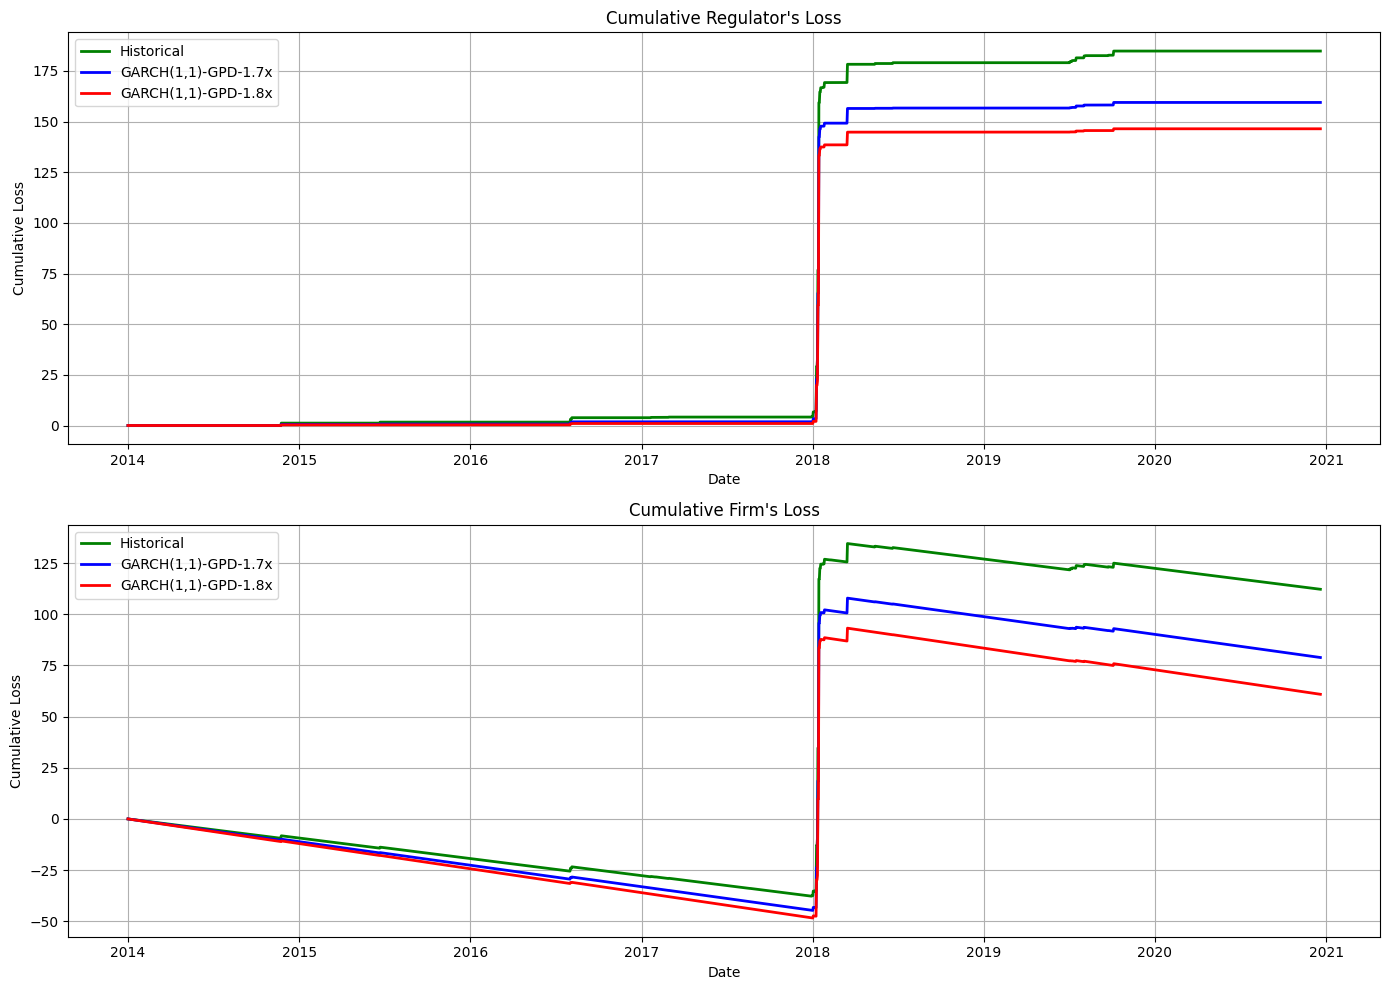


Final Cumulative Losses:

Regulator's Loss:
Historical: 184.79
GARCH(1,1)-GPD-1.7x: 159.42
GARCH(1,1)-GPD-1.8x: 146.43

Firm's Loss:
Historical: 112.20
GARCH(1,1)-GPD-1.7x: 78.85
GARCH(1,1)-GPD-1.8x: 60.88


In [23]:
# Plot cumulative losses for specified models
plt.figure(figsize=(14, 10))

# Specify the models we want to compare
models_to_compare = ['Historical', 'GARCH(1,1)-GPD-1.7x', 'GARCH(1,1)-GPD-1.8x']
colors = ['g', 'b', 'r']  # green for historical, blue for 1.7x, red for 1.8x

reg_losses_df = pd.DataFrame(index=test_dates)
firm_losses_df = pd.DataFrame(index=test_dates)

for model_name, data in model_data.items():
    if model_name in models_to_compare:
        var_estimates = data['vars']
        reg_losses = regulator_loss_function(test_returns, var_estimates)
        firm_losses = firm_loss_function(test_returns, var_estimates, i=i_rate)

        reg_losses_df[model_name] = reg_losses
        firm_losses_df[model_name] = firm_losses

plt.subplot(2, 1, 1)
for i, model in enumerate(models_to_compare):
    if model in reg_losses_df.columns:
        plt.plot(test_dates, np.cumsum(reg_losses_df[model]),
                color=colors[i],
                label=model,
                linewidth=2)

plt.title("Cumulative Regulator's Loss")
plt.xlabel('Date')
plt.ylabel('Cumulative Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
for i, model in enumerate(models_to_compare):
    if model in firm_losses_df.columns:
        plt.plot(test_dates, np.cumsum(firm_losses_df[model]),
                color=colors[i],
                label=model,
                linewidth=2)

plt.title("Cumulative Firm's Loss")
plt.xlabel('Date')
plt.ylabel('Cumulative Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final cumulative losses
print("\nFinal Cumulative Losses:")
print("\nRegulator's Loss:")
for model in models_to_compare:
    if model in reg_losses_df.columns:
        final_loss = np.sum(reg_losses_df[model])
        print(f"{model}: {final_loss:.2f}")

print("\nFirm's Loss:")
for model in models_to_compare:
    if model in firm_losses_df.columns:
        final_loss = np.sum(firm_losses_df[model])
        print(f"{model}: {final_loss:.2f}")

Of the models which pass adequacy and accuracy tests, the GARCH(1, 1)-GPD-1.7x model's `exceedance_rate` value is closest to the 0.01 threshold that we expect at a 99% confidence level, consequently, it is the favorite.

In [24]:
results_df

,model,distribution,p,q,var_estimate,exceedance_rate,exceedance_count,expected_rate,total_observations,gpd_shape,gpd_scale,multiplier,uc_lr,uc_pvalue,ind_lr,ind_pvalue,cc_lr,cc_pvalue,regulator_loss,firm_loss
0,Historical,Empirical,-,-,-2.895399,0.014931,38,0.010000,2545,NaN,NaN,NaN,5.428768,0.019808,13.994516,0.000183,19.423284,0.000061,0.072608,0.044086
1,"GARCH(1,1)-GPD",GPD-Hybrid,1,1,-1.882952,0.037721,96,0.010000,2545,0.115036,0.595120,1.000000,0.835736,0.360619,1.918376,0.166036,2.754112,0.252320,0.130236,0.112117
2,"GARCH(1,1)-GPD-1.1x",GPD-Hybrid,1,1,-2.071247,0.031041,79,0.010000,2545,0.115036,0.595120,1.100000,73.017964,0.000000,11.474378,0.000706,84.492342,0.000000,0.115534,0.095464
3,"GARCH(1,1)-GPD-1.2x",GPD-Hybrid,1,1,-2.259542,0.025540,65,0.010000,2545,0.115036,0.595120,1.200000,43.421399,0.000000,7.351669,0.006700,50.773068,0.000000,0.103016,0.080997
4,"GARCH(1,1)-GPD-1.3x",GPD-Hybrid,1,1,-2.447837,0.022004,56,0.010000,2545,0.115036,0.595120,1.300000,27.599157,0.000000,7.004108,0.008132,34.603264,0.000000,0.092315,0.068375
5,"GARCH(1,1)-GPD-1.4x",GPD-Hybrid,1,1,-2.636132,0.017682,45,0.010000,2545,0.115036,0.595120,1.400000,12.347296,0.000442,10.801506,0.001014,23.148802,0.000009,0.083158,0.057262
6,"GARCH(1,1)-GPD-1.5x",GPD-Hybrid,1,1,-2.824427,0.014931,38,0.010000,2545,0.115036,0.595120,1.500000,5.428768,0.019808,13.994516,0.000183,19.423284,0.000061,0.075279,0.047456
7,"GARCH(1,1)-GPD-1.6x",GPD-Hybrid,1,1,-3.012722,0.012574,32,0.010000,2545,0.115036,0.595120,1.600000,1.574333,0.209579,7.298814,0.006900,8.873147,0.011836,0.068509,0.038761
8,"GARCH(1,1)-GPD-1.7x",GPD-Hybrid,1,1,-3.201018,0.011002,28,0.010000,2545,0.115036,0.595120,1.700000,0.249953,0.617108,1.005571,0.315966,1.255524,0.533785,0.062642,0.030984
9,"GARCH(1,1)-GPD-1.8x",GPD-Hybrid,1,1,-3.389313,0.008251,21,0.010000,2545,0.115036,0.595120,1.800000,0.835736,0.360619,1.918376,0.166036,2.754112,0.252320,0.057535,0.023921


## Conclusion
We have effectively demonstrated how to implement a comprehensive VaR analysis using a parametric univariate GARCH approach which holds up to both adequacy and accuracy tests. By using a Standardized Skew Student's t distribution (to model kurtosis of the empirical distribution) with a Generalized Pareto (left) Tail and applying a soft multiplier of 1.7x we were able to construct a return distribution that, when fed through a GARCH(1, 1) model, produced a statistically significant and accurate VaR estimate.

Recent literature shows that while GARCH-EVT hybrid approaches remain foundational in VaR estimation, there is a significant trend toward combining traditional econometric methods with machine learning techniques. Buczynski and Chlebus (2023) introduced GARCHNet, which adapts LSTM neural network architecture to GARCH specifications, demonstrating improved VaR forecasting capabilities. Michańków et al. (2023) developed a hybrid approach combining GARCH models with Gated Recurrent Unit (GRU) networks, finding that while hybrid solutions produce more accurate point volatility forecasts, this doesn't necessarily translate to superior VaR estimates. This supports our methodological choice of maintaining a parsimonious GARCH-EVT approach with the Skewed Student's t distribution, as it balances sophisticated tail modeling with interpretability. The effectiveness of our GPD-Hybrid distribution aligns with current research trends, where the focus remains on improving tail estimation while maintaining model tractability for regulatory purposes.